# 🎙️ Feedback Amplifier Activity: Microphone → Amplifier → Speaker

## Objective

In this activity, you will explore how a **common-emitter (CE) amplifier with shunt feedback** processes an audio signal end-to-end:

1. **Generate** a short musical sound using Python (as if it were captured by a condenser microphone)
2. **Model** the microphone output as a small voltage waveform and encode it as a **PWL (Piecewise-Linear)** source for ngspice
3. **Simulate** the amplifier in ngspice — the bias is established by the current mirror, not a pre-computed DC offset; simulations yield the **DC transfer curve**, **transient response**, and **AC frequency response**
4. **Plot** the three analyses in stacked subplots
5. **Reconstruct** and listen to the amplified audio signal

---

## Circuit Description

```
     VCC (9 V)
     │           │
   Iref(1mA)    Rc          ← Collector load
     │           │
   Vref    ┌────Vc  (output)
     │     │    │
   Qref  [Rf]  Q1  2N3904
  (diode)  │    │
     │    Vbase──┘
    GND     │
   [Vin: audio source in series]
     │
   Vbase──┤B
          │  Q1
          │C  E
          │    │
         Vc   Re
          │    │
         Rc  GND
          │
         VCC
```

```
         VCC
          │
   Iref──►│ (1 mA current source)
          │
         Vref
          ├── Qref (2N3904, diode-connected: C=B=Vref, E=GND)
          │
         [Vin]  ← audio / mic signal injected here
          │
         Vbase ──── Q1 base
                    Q1: collector→Vc, emitter→Ve
                     │          │
                    Rc         Re
                     │          │
                    VCC        GND
         Vc ────── Rf ────── Vbase   (shunt feedback)
```

| Component | Role |
|-----------|------|
| **Iref** | 1 mA reference current source — sets the mirror current |
| **Qref** | Diode-connected 2N3904 — fixes Vref = Vbe ≈ 0.67 V |
| **Vin** | Audio source — injected **in series** between Vref (Qref) and Vbase (Q1 base) |
| **Q1** | 2N3904 NPN BJT — common-emitter amplifier stage |
| **Rf** | Shunt feedback — connects **collector → base**; shapes gain and frequency response |
| **Rc** | Collector resistor — converts collector current to output voltage |
| **Re** | Emitter degeneration — improves linearity and stability |

---

## Questions to Consider

- How does increasing **Rf** affect the gain? The quiescent collector voltage?
- How does **Re** affect linearity and bandwidth?
- What is the approximate midband voltage gain? Compare to the formula **A_v ≈ −(Rf ∥ Rc) / (1/g_m + Re)**
- What is the −3 dB frequency of your amplifier?

---

## Instructions

1. **Edit Cell 2** — set your desired values for `Rf`, `Rc`, `Re`.
2. **Run all cells** from top to bottom (`Kernel → Restart & Run All`).
3. Observe the plots and listen to the reconstructed audio.


In [54]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║          EDIT THIS CELL — Amplifier Component Values            ║
# ╚══════════════════════════════════════════════════════════════════╝

Rf  = 47e3   # Shunt feedback resistance  [Ω]  (e.g. 47e3, 100e3, 220e3)
# Rf = 10e12
Rc  = 4.5e3    # Collector resistance       [Ω]  (e.g. 1e3,  2.2e3, 4.7e3)
Re  = 100    # Emitter resistance         [Ω]  (e.g. 100,  220,   470)
VCC  = 9.0    # Supply voltage             [V]
Iref = 1e-3  # Reference (mirror) current [A]  (e.g. 0.5e-3, 1e-3, 2e-3)

# ── Condenser mic signal amplitude ──────────────────────────────────────────
# Typical condenser mic: ~6 mV/Pa; loud music at 1 m ≈ 1 Pa → ~6 mV peak.
# Increase to hear more amplification (keep < 200 mV to stay in linear region).
Vmic = 0.05  # Microphone peak amplitude  [V]  (e.g. 0.01, 0.05, 0.1)

# ── Print summary ────────────────────────────────────────────────────────────
print(f"Shunt feedback Rf  = {Rf/1e3:.1f} kΩ")
print(f"Collector load  Rc  = {Rc/1e3:.2f} kΩ")
print(f"Emitter degen.  Re  = {Re:.0f} Ω")
print(f"Supply          VCC  = {VCC:.1f} V")
print(f"Mirror current  Iref = {Iref*1000:.1f} mA")
print(f"Mic amplitude   Vmic = {Vmic*1000:.0f} mV peak")


Shunt feedback Rf  = 47.0 kΩ
Collector load  Rc  = 4.50 kΩ
Emitter degen.  Re  = 100 Ω
Supply          VCC  = 9.0 V
Mirror current  Iref = 1.0 mA
Mic amplitude   Vmic = 50 mV peak


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import subprocess, tempfile, os, re, warnings
from scipy.interpolate import interp1d
from IPython.display import Audio, display

warnings.filterwarnings('ignore')
print("Libraries loaded ✓")


Libraries loaded ✓


Audio signal: 2000 samples | 250 ms | 8000 Hz
Notes: C4 → E4 → G4 → C5 (C-major arpeggio)


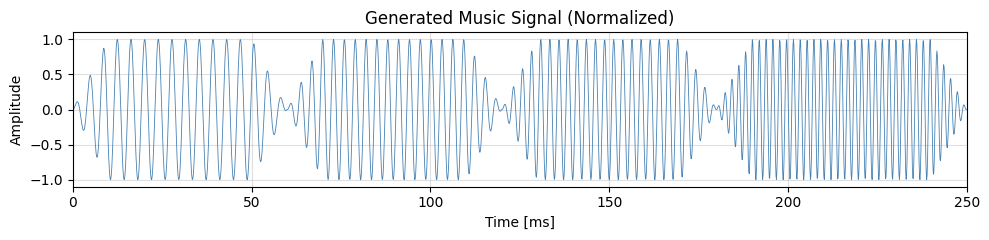


Original audio:


In [56]:
# ── Audio parameters ──────────────────────────────────────────────────────────
Fs      = 8000     # sample rate [Hz]
t_total = 0.25     # total duration [s]
t       = np.arange(int(Fs * t_total)) / Fs   # time axis

# ── Compose a short C-major arpeggio (C4 → E4 → G4 → C5) ────────────────────
notes = [
    (261.63, 0.00, 0.06),   # C4
    (329.63, 0.06, 0.12),   # E4
    (392.00, 0.12, 0.18),   # G4
    (523.25, 0.18, 0.25),   # C5
]

audio = np.zeros_like(t)
for freq, t_on, t_off in notes:
    mask    = (t >= t_on) & (t < t_off)
    t_note  = t[mask] - t_on
    fade    = max(1, int(0.010 * Fs))          # 10 ms fade in/out
    env     = np.ones(mask.sum())
    env[:fade]  = np.linspace(0, 1, fade)
    env[-fade:] = np.linspace(1, 0, fade)
    audio[mask] = env * np.sin(2 * np.pi * freq * t_note)

audio /= np.max(np.abs(audio) + 1e-12)        # normalize to ±1

print(f"Audio signal: {len(t)} samples | {t_total*1000:.0f} ms | {Fs} Hz")
print(f"Notes: C4 → E4 → G4 → C5 (C-major arpeggio)")

plt.figure(figsize=(10, 2.5))
plt.plot(t * 1000, audio, linewidth=0.6, color='steelblue')
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('Generated Music Signal (Normalized)')
plt.xlim(0, t_total * 1000); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print("\nOriginal audio:")
display(Audio(audio, rate=Fs, normalize=False))


In [57]:
# ── Condenser Microphone Model ────────────────────────────────────────────────
# A condenser mic converts sound pressure to a small AC voltage.
# We scale the normalized audio to ±Vmic volts (peak).
V_mic = Vmic * audio                 # mic voltage signal [V]
print(f"Mic signal: ±{Vmic*1000:.0f} mV peak, RMS = {np.sqrt(np.mean(V_mic**2))*1000:.1f} mV")

# ── 2N3904 BJT Model (ngspice parameters) ─────────────────────────────────────
BJT_MODEL = """.model 2N3904 NPN(IS=6.734f XTI=3 EG=1.11 VAF=74.03 BF=416.4 NE=1.259
+ ISE=6.734f IKF=66.78m XTB=1.5 BR=.7371 NC=2 ISC=0 IKR=0 RC=1
+ CJC=3.638p MJC=.3085 VJC=.75 FC=.5 CJE=4.493p MJE=.2593 VJE=.75
+ TR=239.5n TF=301.2p ITF=.4 VTF=4 XTF=2 RB=10)"""

# ── Bias note ─────────────────────────────────────────────────────────────────
# The DC operating point is established entirely by the current mirror:
#   Iref sets ≈1 mA through Qref (diode-connected), fixing Vref ≈ Vbe ≈ 0.67 V.
#   Q1's base is tied to Vref (through the Vin series source at DC = 0 V),
#   so Q1 nominally mirrors Iref.  The shunt feedback Rf is still present and
#   modifies the effective operating point, but there is no separate .op run.
print("BJT model defined.  DC bias will be set by the current mirror in the netlist.")


Mic signal: ±50 mV peak, RMS = 31.4 mV
BJT model defined.  DC bias will be set by the current mirror in the netlist.


In [58]:
# ── Build PWL string: pure AC mic signal (no DC offset — bias is in circuit) ──
# V(Vbase) = V(Vref) + Vin  →  Vin = V_mic (centred on 0 V)
pwl_str = " ".join(f"{t[i]:.7e} {V_mic[i]:.7f}" for i in range(len(t)))
pwl_str += f" {t[-1] + 1/Fs:.7e} {V_mic[-1]:.7f}"

# ── Simulation parameters ─────────────────────────────────────────────────────
Vac_src      = 1e-3         # AC amplitude for small-signal analysis [V]
Vin_sw_start = -0.2         # DC sweep start  [V]  (offset around operating point)
Vin_sw_stop  =  0.2         # DC sweep stop   [V]
Vin_sw_step  =  0.002       # DC sweep step   [V]

tstep  = 1 / Fs             # transient step = audio sample period [s]
tstop  = t_total + tstep    # total simulation time [s]

# ── Output file paths ─────────────────────────────────────────────────────────
sim_dir   = tempfile.mkdtemp()
dc_file   = os.path.join(sim_dir, 'dc_out.txt')
tran_file = os.path.join(sim_dir, 'tran_out.txt')
ac_file   = os.path.join(sim_dir, 'ac_out.txt')
cir_file  = os.path.join(sim_dir, 'amplifier.cir')

# ── Build ngspice netlist via f-string ───────────────────────────────────────
netlist = f"""* ═══════════════════════════════════════════════════════════════════════
* Common-Emitter Amplifier — Current Mirror Bias + Shunt Feedback
* Student Activity
* ═══════════════════════════════════════════════════════════════════════
{BJT_MODEL}

* ── Power supply ──────────────────────────────────────────────────────────────
Vcc VCC 0 DC {VCC}

* ── Current mirror bias ───────────────────────────────────────────────────────
* 1 mA reference current source pulls Vref toward the diode voltage
Iref VCC Vref DC {Iref}
* Diode-connected 2N3904 reference transistor: collector = base = Vref
Qref Vref Vref 0 2N3904

* ── Input source (audio signal) ───────────────────────────────────────────────
* Placed in series between Qref (Vref) and Q1 base (Vbase).
* At DC=0 this source is a short, so Vbase = Vref (mirror sets bias).
* AC / PWL waveform modulates Vbase around the quiescent point.
Vin Vbase Vref DC 0 AC {Vac_src} PWL({pwl_str})

* ── Main CE amplifier ─────────────────────────────────────────────────────────
Q1  Vc  Vbase  Ve  2N3904
Rc  VCC Vc     {Rc}
Re  Ve  0      {Re}
Rf  Vc  Vbase  {Rf}

* ══ Analyses ══════════════════════════════════════════════════════════════════
.control

  * ── 1. DC Transfer Curve ───────────────────────────────────────────────────
  * Sweep the series input source Vin.DC around the quiescent point.
  * X-axis = Vin offset; Y-axis = Vc (output).
  dc Vin {Vin_sw_start} {Vin_sw_stop} {Vin_sw_step}
  wrdata {dc_file} v(vc) v(vbase)
  echo DC_DONE

  * ── 2. Transient Analysis (audio signal) ────────────────────────────────────
  tran {tstep:.6e} {tstop:.6f}
  wrdata {tran_file} v(vbase) v(vc)
  echo TRAN_DONE

  * ── 3. AC Small-Signal Frequency Response ───────────────────────────────────
  ac dec 100 10 1000Meg
  wrdata {ac_file} v(vc)
  echo AC_DONE

.endc
.end
"""

with open(cir_file, 'w') as f:
    f.write(netlist)

print(f"Netlist written: {cir_file}")
print(f"PWL points  : {len(t)+1}")
print(f"Tran duration: {tstop*1000:.1f} ms  |  step: {tstep*1e6:.0f} µs")
print(f"DC sweep    : Vin = {Vin_sw_start} V → {Vin_sw_stop} V  (input offset around Q-point)")
print("\nRunning ngspice ...  (this may take a few seconds)")

result = subprocess.run(
    ['ngspice', '-b', cir_file],
    capture_output=True, text=True, timeout=300
)
ngspice_out = result.stdout + result.stderr

if 'DC_DONE' not in ngspice_out:
    raise RuntimeError("DC analysis failed.\n" + ngspice_out[-2000:])
if 'TRAN_DONE' not in ngspice_out:
    raise RuntimeError("Transient analysis failed.\n" + ngspice_out[-2000:])
if 'AC_DONE' not in ngspice_out:
    raise RuntimeError("AC analysis failed.\n" + ngspice_out[-2000:])

print("\nngspice simulation complete ✓")
print("  DC  data  →", dc_file)
print("  Tran data →", tran_file)
print("  AC  data  →", ac_file)


Netlist written: /tmp/tmpqgep4bys/amplifier.cir
PWL points  : 2001
Tran duration: 250.1 ms  |  step: 125 µs
DC sweep    : Vin = -0.2 V → 0.2 V  (input offset around Q-point)

Running ngspice ...  (this may take a few seconds)

ngspice simulation complete ✓
  DC  data  → /tmp/tmpqgep4bys/dc_out.txt
  Tran data → /tmp/tmpqgep4bys/tran_out.txt
  AC  data  → /tmp/tmpqgep4bys/ac_out.txt


DC   : 201 points  Vc range 0.80 – 8.25 V
Tran : 8840 points  time  0.00 – 250.1 ms
AC   : 801 points  freq  10 Hz – 1000 MHz

Q-point (Vin=0, from DC sweep):
  Vc  ≈ 6.898 V   Ic ≈ 0.47 mA   gm ≈ 18.0 mS
  Estimated midband gain  Av ≈ -26.4  (28.4 dB)

Midband gain : 27.0 dB
−3 dB band   : < 10 Hz  –  17.8 MHz
Bandwidth    ≈ 18 MHz  (lower limit of sweep — flat to DC)


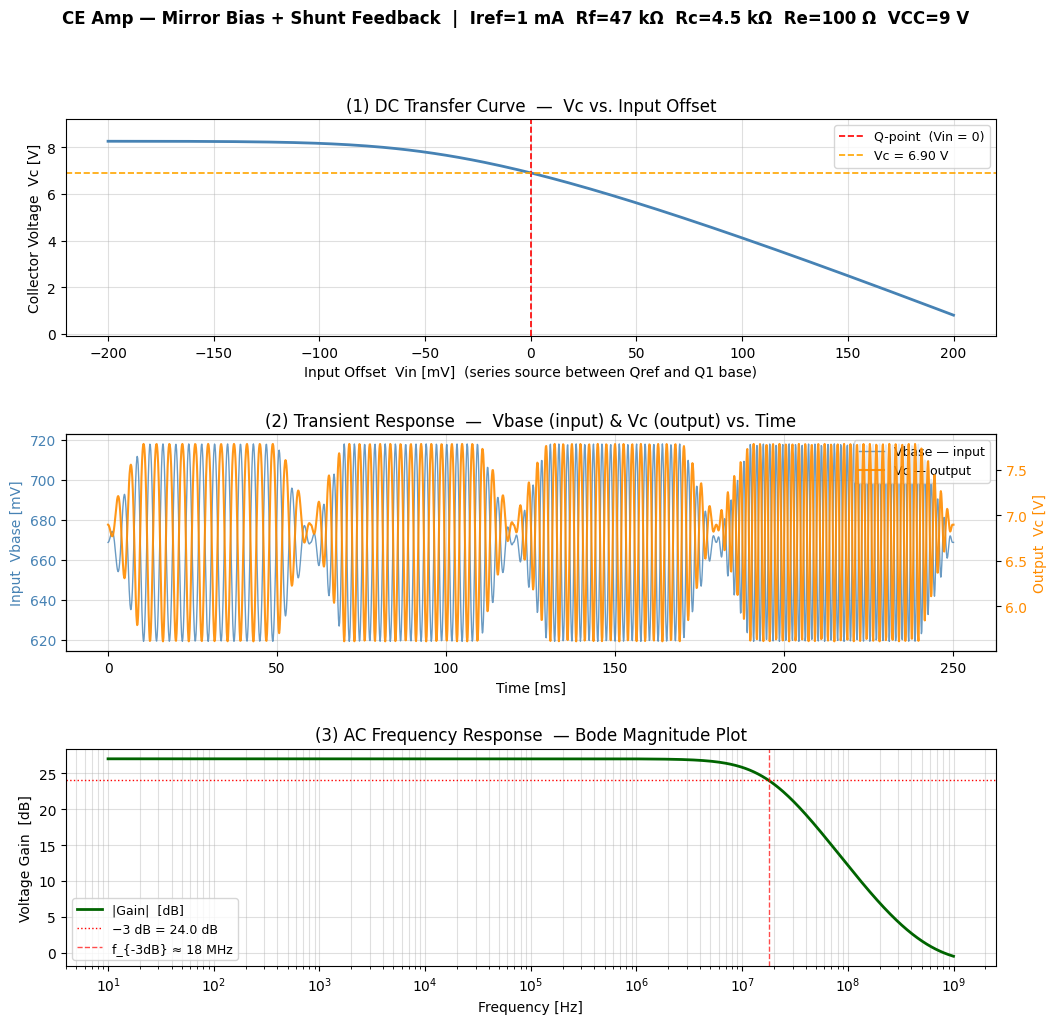

Plot saved to results.png ✓


In [59]:
# ── Parser for ngspice wrdata output ─────────────────────────────────────────
# ngspice wrdata format (for N vectors):
#   x  v1  x  v2  x  v3  ...   (x repeats before each vector)
# For AC: x  re(v1)  im(v1)     (complex format, no x-repeat)
def parse_wrdata(filepath, n_vars, is_complex=False):
    """Return (x_axis, var1, var2, ...) arrays from a wrdata file."""
    rows = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line and not line.startswith('*'):
                try:
                    rows.append([float(v) for v in line.split()])
                except ValueError:
                    pass
    data = np.array(rows)
    if is_complex:
        # columns: freq, re(v1), im(v1)
        return (data[:, 0],) + tuple(
            data[:, 1 + 2*i] + 1j * data[:, 2 + 2*i]
            for i in range(n_vars)
        )
    else:
        # columns: x, v1, x, v2, ...  (step = 2)
        x = data[:, 0]
        vecs = [data[:, 1 + 2*i] for i in range(n_vars)]
        return (x,) + tuple(vecs)

# ── Load simulation results ───────────────────────────────────────────────────
# DC:  wrdata v(vc) v(vbase)  →  cols: x(=Vin_sweep), vc, x(repeated), vbase
dc_raw        = parse_wrdata(dc_file, 2, is_complex=False)
dc_vin_offset = dc_raw[0]   # x-axis = Vin DC offset swept [V]
dc_vc         = dc_raw[1]   # collector voltage Vc [V]

# Tran: wrdata v(vbase) v(vc)
tr_t, tr_vbase, tr_vc = parse_wrdata(tran_file, 2, is_complex=False)

# AC: wrdata v(vc)  (complex)
ac_data = parse_wrdata(ac_file, 1, is_complex=True)
ac_f    = ac_data[0]
ac_vc_c = ac_data[1]   # complex collector voltage

ac_gain_dB  = 20 * np.log10(np.abs(ac_vc_c) / Vac_src + 1e-12)
ac_phase_deg= np.degrees(np.angle(ac_vc_c))

# ── Extract quiescent operating point (Vin=0) from DC sweep ──────────────────
idx_q   = int(np.argmin(np.abs(dc_vin_offset)))
Vc_bias = float(dc_vc[idx_q])
Ic_bias = (VCC - Vc_bias) / Rc
gm      = Ic_bias / 0.026          # transconductance [S]
Rout    = (Rf * Rc) / (Rf + Rc)    # Rf ∥ Rc [Ω]
Av_est  = -gm * Rout / (1 + gm * Re)  # small-signal gain estimate

print(f"DC   : {len(dc_vin_offset)} points  Vc range {dc_vc.min():.2f} – {dc_vc.max():.2f} V")
print(f"Tran : {len(tr_t)} points  time  {tr_t[0]*1e3:.2f} – {tr_t[-1]*1e3:.1f} ms")
print(f"AC   : {len(ac_f)} points  freq  {ac_f[0]:.0f} Hz – {ac_f[-1]/1e6:.0f} MHz")
print(f"\nQ-point (Vin=0, from DC sweep):")
print(f"  Vc  ≈ {Vc_bias:.3f} V   Ic ≈ {Ic_bias*1000:.2f} mA   gm ≈ {gm*1000:.1f} mS")
print(f"  Estimated midband gain  Av ≈ {Av_est:.1f}  ({20*np.log10(abs(Av_est)):.1f} dB)")

# ── Find -3 dB frequencies ────────────────────────────────────────────────────
gain_mid = np.max(ac_gain_dB)
mask_3dB = ac_gain_dB >= (gain_mid - 3)
f3dB_lo  = f3dB_hi = None
print(f"\nMidband gain : {gain_mid:.1f} dB")
if mask_3dB.any():
    f3dB_lo = ac_f[mask_3dB][0]
    f3dB_hi = ac_f[mask_3dB][-1]
    at_lo   = (f3dB_lo == ac_f[0])
    at_hi   = (f3dB_hi == ac_f[-1])
    lo_str  = (f"< {ac_f[0]:.0f} Hz") if at_lo  else f"{f3dB_lo:.0f} Hz"
    hi_str  = (f"> {ac_f[-1]/1e6:.0f} MHz") if at_hi else (
              f"{f3dB_hi/1e6:.1f} MHz" if f3dB_hi >= 1e6 else f"{f3dB_hi/1e3:.0f} kHz")
    bw      = f3dB_hi - f3dB_lo
    bw_str  = f"{bw/1e6:.0f} MHz" if bw >= 1e6 else f"{bw/1e3:.0f} kHz"
    print(f"−3 dB band   : {lo_str}  –  {hi_str}")
    print(f"Bandwidth    ≈ {bw_str}  {'(lower limit of sweep — flat to DC)' if at_lo else ''}")

# ════════════════════════════════════════════════════════════════════════════════
# ── Stacked plots ────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(12, 11))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# ── Subplot 1: DC Transfer Curve ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(dc_vin_offset * 1e3, dc_vc, color='steelblue', linewidth=2)
ax1.axvline(0, color='red',    linestyle='--', linewidth=1.2, label='Q-point  (Vin = 0)')
ax1.axhline(Vc_bias, color='orange', linestyle='--', linewidth=1.2, label=f'Vc = {Vc_bias:.2f} V')
ax1.set_xlabel('Input Offset  Vin [mV]  (series source between Qref and Q1 base)')
ax1.set_ylabel('Collector Voltage  Vc [V]')
ax1.set_title('(1) DC Transfer Curve  —  Vc vs. Input Offset')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.4)
ax1.set_ylim(-0.1, VCC + 0.2)

# ── Subplot 2: Transient Response ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2_twin = ax2.twinx()
ax2.plot(tr_t * 1e3, tr_vbase * 1e3, color='steelblue', linewidth=1,   label='Vbase — input',  alpha=0.8)
ax2_twin.plot(tr_t * 1e3, tr_vc,     color='darkorange', linewidth=1.5, label='Vc — output', alpha=0.9)
ax2.set_xlabel('Time [ms]')
ax2.set_ylabel('Input  Vbase [mV]',   color='steelblue')
ax2_twin.set_ylabel('Output  Vc [V]', color='darkorange')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2_twin.tick_params(axis='y', labelcolor='darkorange')
ax2.set_title('(2) Transient Response  —  Vbase (input) & Vc (output) vs. Time')
lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.4)

# ── Subplot 3: AC Frequency Response ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.semilogx(ac_f, ac_gain_dB, color='darkgreen', linewidth=2, label='|Gain|  [dB]')
ax3.axhline(gain_mid - 3, color='red', linestyle=':', linewidth=1, label=f'−3 dB = {gain_mid-3:.1f} dB')
if f3dB_hi is not None and f3dB_hi < ac_f[-1]:
    ax3.axvline(f3dB_hi, color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'f_{{-3dB}} ≈ {f3dB_hi/1e6:.0f} MHz')
ax3.set_xlabel('Frequency [Hz]')
ax3.set_ylabel('Voltage Gain  [dB]')
ax3.set_title('(3) AC Frequency Response  — Bode Magnitude Plot')
ax3.legend(fontsize=9); ax3.grid(True, which='both', alpha=0.4)

fig.suptitle(
    f'CE Amp — Mirror Bias + Shunt Feedback  |  Iref={Iref*1000:.0f} mA  Rf={Rf/1e3:.0f} kΩ  Rc={Rc/1e3:.1f} kΩ  Re={Re:.0f} Ω  VCC={VCC:.0f} V',
    fontsize=12, fontweight='bold'
)
plt.savefig(os.path.join(sim_dir, 'results.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved to results.png ✓")


Output signal peak-to-peak : 1206.4 mV  (input ±50 mV → output ±1206.4 mV)
Measured gain magnitude    : 24.13  (estimated: 26.4)


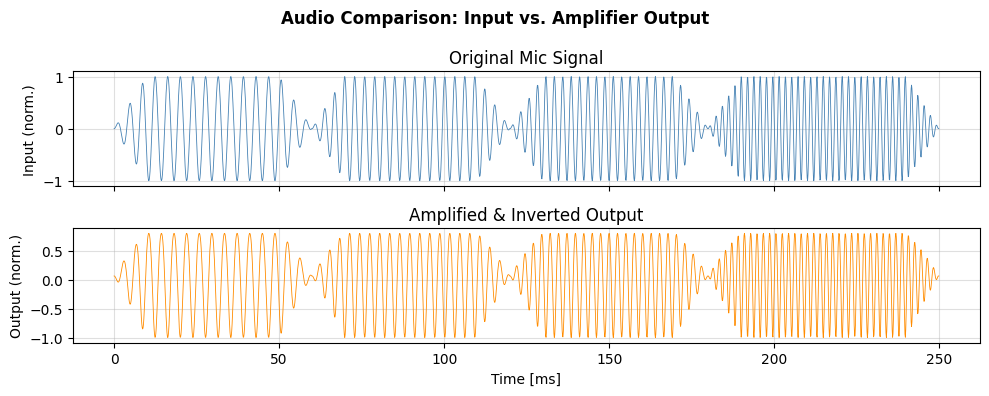


🎵 Original audio:



🔊 Amplified audio (note: phase is inverted — this is normal for CE amplifier):


In [60]:
# ── Interpolate transient output onto uniform audio grid ─────────────────────
t_uniform  = np.arange(int(Fs * t_total)) / Fs          # uniform time axis [s]

# Clamp interpolation to the simulated time range
t_clamp = np.clip(t_uniform, tr_t[0], tr_t[-1])
interp_vc  = interp1d(tr_t, tr_vc, kind='linear', bounds_error=False,
                       fill_value=(tr_vc[0], tr_vc[-1]))
vc_uniform = interp_vc(t_clamp)

# ── Remove DC bias, normalize ─────────────────────────────────────────────────
audio_out      = vc_uniform - np.mean(vc_uniform)        # AC component only
peak           = np.max(np.abs(audio_out))
if peak < 1e-6:
    raise ValueError("Output signal is essentially zero — check operating point.")
audio_out_norm = audio_out / peak                        # normalized to ±1

print(f"Output signal peak-to-peak : {peak*1000:.1f} mV  (input ±{Vmic*1000:.0f} mV → output ±{peak*1000:.1f} mV)")
print(f"Measured gain magnitude    : {peak / Vmic:.2f}  (estimated: {abs(Av_est):.1f})")

# ── Side-by-side comparison plot ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t * 1e3, audio,        linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Input (norm.)'); axes[0].set_title('Original Mic Signal')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_uniform * 1e3, audio_out_norm, linewidth=0.6, color='darkorange')
axes[1].set_ylabel('Output (norm.)'); axes[1].set_title('Amplified & Inverted Output')
axes[1].set_xlabel('Time [ms]'); axes[1].grid(True, alpha=0.4)

plt.suptitle('Audio Comparison: Input vs. Amplifier Output', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Play back both signals ─────────────────────────────────────────────────────
print("\n🎵 Original audio:")
display(Audio(audio,         rate=Fs, normalize=False))

print("\n🔊 Amplified audio (note: phase is inverted — this is normal for CE amplifier):")
display(Audio(audio_out_norm, rate=Fs, normalize=False))
